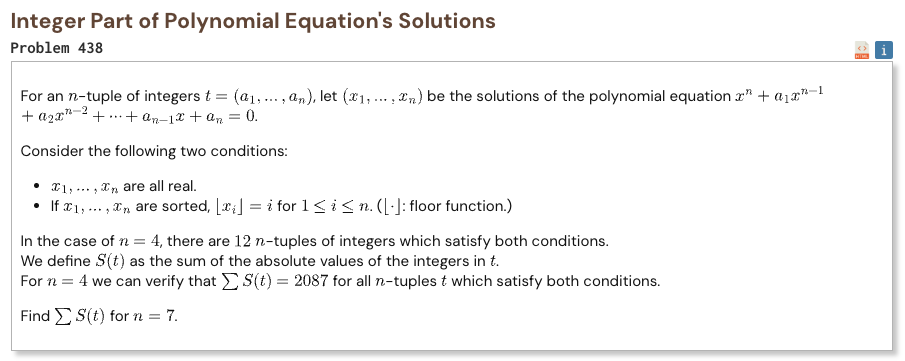

## Initial approach

-   each root must lie between its required integer and the next integer
-   this means the polynomial values just before consecutive integers must alternate signs
-   use forward differences to remove the lower degree coefficients step by step
-   at each step the next coefficient has a small exact integer range instead of an enormous search space
-   represent values near an integer with epsilon coefficients so roots exactly on an integer are handled correctly
-   recursively choose the valid coefficients and update the remaining inequalities
-   for the final coefficient sum the whole valid range directly instead of testing every value separately

In [1]:
%%time

from math import comb

n = 7

def sum_abs_range(lo, hi):
    if hi < 0:
        count = hi - lo + 1
        return -(lo + hi) * count // 2

    if lo > 0:
        count = hi - lo + 1
        return (lo + hi) * count // 2

    return (-lo) * (-lo + 1) // 2 + hi * (hi + 1) // 2

def first_nonzero_sign(values):
    for value in values[1:]:
        if value > 0:
            return 1
        if value < 0:
            return -1
    return 0

def build_tables(n):
    shifted = {}

    for base in range(1, 2 * n + 2):
        for power in range(n + 1):
            values = [0] * (n + 1)

            for e in range(power + 1):
                values[e] = (
                    comb(power, e)
                    * base ** (power - e)
                    * (-1) ** e
                )

            shifted[base, power] = values

    table = [
        [
            [None] * (n + 1)
            for _ in range(n + 2)
        ]
        for _ in range(n + 1)
    ]

    coefficient = [
        [0] * (n + 2)
        for _ in range(n + 1)
    ]

    for k in range(1, n + 1):
        d = n - k

        factorial = 1
        for value in range(2, d + 1):
            factorial *= value

        for m in range(1, k + 2):
            sign = 1 if (k + 1 - m) % 2 == 0 else -1

            for i in range(k + 1):
                power = n - i
                values = [0] * (n + 1)

                for j in range(d + 1):
                    factor = (-1) ** (d - j) * comb(d, j)
                    poly = shifted[m + j, power]

                    for e in range(n + 1):
                        values[e] += factor * poly[e]

                if sign == -1:
                    values = [-value for value in values]

                table[k][m][i] = values

            coefficient[k][m] = sign * factorial

    return table, coefficient

table, coefficient = build_tables(n)

current = [
    [None] * (n + 2)
    for _ in range(n + 1)
]

for k in range(1, n + 1):
    for m in range(1, k + 2):
        current[k][m] = table[k][m][0].copy()

def update(index, value):
    if value == 0:
        return

    for k in range(index + 1, n + 1):
        for m in range(1, k + 2):
            source = table[k][m][index]
            target = current[k][m]

            for e in range(n + 1):
                target[e] += value * source[e]

def get_bound(a, values):
    b = values[0]

    if a > 0:
        num = -b

        if num % a:
            return "lower", num // a + 1

        value = num // a
        sign = first_nonzero_sign(values)

        if sign > 0:
            return "lower", value

        return "lower", value + 1

    a = -a
    num = b

    if num % a:
        return "upper", num // a

    value = num // a
    sign = first_nonzero_sign(values)

    if sign > 0:
        return "upper", value

    return "upper", value - 1

def bounds(k):
    lower = -(10 ** 30)
    upper = 10 ** 30

    for m in range(1, k + 2):
        kind, value = get_bound(
            coefficient[k][m],
            current[k][m]
        )

        if kind == "lower":
            lower = max(lower, value)
        else:
            upper = min(upper, value)

    return lower, upper

result = 0

def search(k, prefix_sum):
    global result

    lower, upper = bounds(k)

    if lower > upper:
        return

    if k == n:
        count = upper - lower + 1
        result += count * prefix_sum
        result += sum_abs_range(lower, upper)
        return

    for value in range(lower, upper + 1):
        update(k, value)
        search(k + 1, prefix_sum + abs(value))
        update(k, -value)

search(1, 0)

print("Result:", result)

Result: 2046409616809
CPU times: user 54.2 s, sys: 205 ms, total: 54.4 s
Wall time: 54.6 s
